In [2]:
import pandas as pd

paths = {
    'parquet': 'data/silver/customer_churn_silver.parquet',
    'csv': 'data/silver/customer_churn_silver.csv'
}

try:
    df = pd.read_parquet(paths['parquet'])
    print('Loaded silver data from Parquet')
except Exception as exc:
    df = pd.read_csv(paths['csv'])

print('Data shape:', df.shape)
df.head()

Loaded silver data from Parquet
Data shape: (10000, 16)


,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


**Business Problem**

The bank aims to understand the characteristics of customers who are likely to churn and identify business opportunities to improve customer retention.

The analysis will answer five key business questions:

1. What does the customer base look like?
2. Which customer groups have the highest churn rate?
3. How do financial characteristics relate to churn?
4. How does customer experience influence churn?
5. Which factors should management prioritize?

***Question 1 : What does the customer base look like?***

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")

print("\nCustomers by Geography:")
print(
    df["Geography"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .astype(str) + "%"
)

print("\nCustomers by Gender:")
print(
    df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .astype(str) + "%"
)

print("\nCustomer Age Summary:")
print(df["Age"].describe().round(1))

print("\nTenure Summary:")
print(df["Tenure"].describe().round(1))

print("\nBalance Summary:")
print(df["Balance"].describe().round(2))

print("\nEstimated Salary Summary:")
print(df["EstimatedSalary"].describe().round(2))


Customers by Geography:
Geography
France     50.1%
Germany    25.1%
Spain      24.8%
Name: proportion, dtype: str

Customers by Gender:
Gender
Male      54.6%
Female    45.4%
Name: proportion, dtype: str

Customer Age Summary:
count    10000.0
mean        38.9
std         10.5
min         18.0
25%         32.0
50%         37.0
75%         44.0
max         92.0
Name: Age, dtype: float64

Tenure Summary:
count    10000.0
mean         5.0
std          2.9
min          0.0
25%          3.0
50%          5.0
75%          7.0
max         10.0
Name: Tenure, dtype: float64

Balance Summary:
count     10000.00
mean      76485.89
std       62397.41
min           0.00
25%           0.00
50%       97198.54
75%      127644.24
max      250898.09
Name: Balance, dtype: float64

Estimated Salary Summary:
count     10000.00
mean     100090.24
std       57510.49
min          11.58
25%       51002.11
50%      100193.92
75%      149388.25
max      199992.48
Name: EstimatedSalary, dtype: float64


### Insight

The customer base is concentrated in France (50%), followed by Germany and Spain with approximately 25% each. Male customers slightly outnumber female customers. Most customers are between 30–45 years old, indicating that the bank primarily serves working-age individuals.

***Question 2 : Which customer groups have the highest churn rate?***

In [4]:
def groupChurnRate(col, top=10):
    summary = (
        df
        .groupby(col, observed=True)["Exited"]
        .agg(total="count", churned="sum")
    )

    summary["ChurnRate"] = summary["churned"] / summary["total"]

    return (
        summary
        .sort_values("ChurnRate", ascending=False)
        .head(top)
    )


print("\n========== CUSTOMER GROUP CHURN ANALYSIS ==========")

for col in [
    "Geography",
    "Gender",
    "NumOfProducts",
    "IsActiveMember",
    "HasCrCard",
    "CardType",
    "SatisfactionScore",
    "Complain"
]:
    print(f"\n{col} Churn Rate")
    print(groupChurnRate(col))


========== CUSTOMER GROUP CHURN ANALYSIS ==========

Geography Churn Rate
           total  churned  ChurnRate
Geography                           
Germany     2509      814   0.324432
Spain       2477      413   0.166734
France      5014      811   0.161747

Gender Churn Rate
        total  churned  ChurnRate
Gender                           
Female   4543     1139   0.250715
Male     5457      899   0.164743

NumOfProducts Churn Rate
               total  churned  ChurnRate
NumOfProducts                           
4                 60       60   1.000000
3                266      220   0.827068
1               5084     1409   0.277144
2               4590      349   0.076035

IsActiveMember Churn Rate
                total  churned  ChurnRate
IsActiveMember                           
0                4849     1303   0.268715
1                5151      735   0.142691

HasCrCard Churn Rate
           total  churned  ChurnRate
HasCrCard                           
0           2945      

### Insight 2
Customers from Germany exhibit the highest churn rate (32.4%), nearly double that of France and Spain. Customers with four products show a 100% churn rate, although this group is relatively small. Inactive members also demonstrate substantially higher churn than active members.

***Question 3 : How do financial characteristics relate to churn?*** 


In [5]:
print("\n-- Financial Relationship with Churn --")

print(
    df
    .groupby("Exited")[
        [
            "CreditScore",
            "Balance",
            "EstimatedSalary",
            "PointEarned"
        ]
    ]
    .mean()
    .round(1)
)




-- Financial Relationship with Churn --
        CreditScore  Balance  EstimatedSalary  PointEarned
Exited                                                    
0             651.8  72742.8          99726.9        607.0
1             645.4  91109.5         101509.9        604.4


### Insight

Customers who churn tend to maintain higher account balances than retained customers. However, average credit scores and estimated salaries differ only slightly, suggesting that balance is more indicative of churn than income or creditworthiness.

***Question 4 : How does customer experience influence churn?***


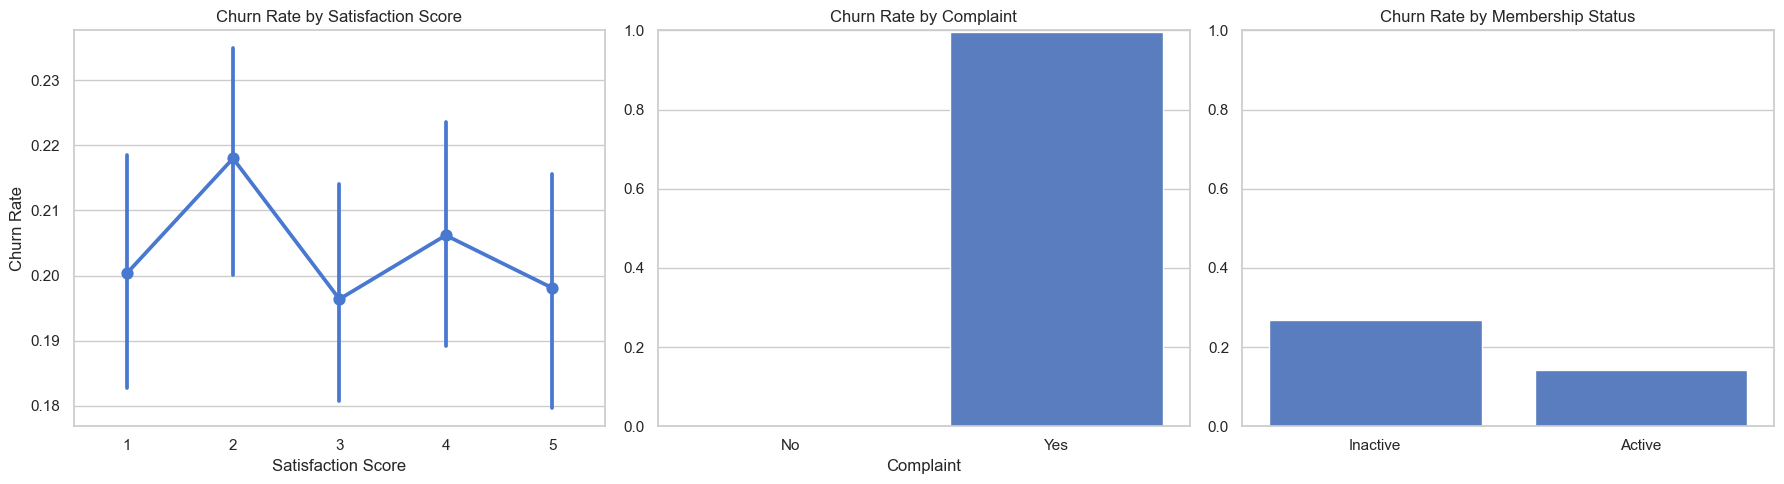

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ==========================
# Satisfaction Score
# ==========================

sns.pointplot(
    data=df,
    x="SatisfactionScore",
    y="Exited",
    order=sorted(df["SatisfactionScore"].unique()),
    ax=axes[0]
)

axes[0].set_title("Churn Rate by Satisfaction Score")
axes[0].set_xlabel("Satisfaction Score")
axes[0].set_ylabel("Churn Rate")

# ==========================
# Complaint
# ==========================

complaint = (
    df.groupby("Complain", as_index=False)["Exited"]
      .mean()
      .rename(columns={"Exited": "ChurnRate"})
)

complaint["Complain"] = complaint["Complain"].map({
    0: "No",
    1: "Yes"
})

sns.barplot(
    data=complaint,
    x="Complain",
    y="ChurnRate",
    ax=axes[1]
)

axes[1].set_title("Churn Rate by Complaint")
axes[1].set_xlabel("Complaint")
axes[1].set_ylabel("")
axes[1].set_ylim(0, 1)

# ==========================
# Membership Status
# ==========================

active = (
    df.groupby("IsActiveMember", as_index=False)["Exited"]
      .mean()
      .rename(columns={"Exited": "ChurnRate"})
)

active["IsActiveMember"] = active["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

sns.barplot(
    data=active,
    x="IsActiveMember",
    y="ChurnRate",
    ax=axes[2]
)

axes[2].set_title("Churn Rate by Membership Status")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

***Question 5 : What are the key drivers of churn?***

In [7]:
print("\n-- Correlation with Churn --")

correlation = df[
    [
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "HasCrCard",
        "IsActiveMember",
        "EstimatedSalary",
        "Complain",
        "SatisfactionScore",
        "PointEarned",
        "Exited"
    ]
].corr()

print(
    correlation["Exited"]
    .sort_values(ascending=False)
    .round(3)
)


-- Correlation with Churn --
Exited               1.000
Complain             0.996
Age                  0.285
Balance              0.119
EstimatedSalary      0.012
PointEarned         -0.005
SatisfactionScore   -0.006
HasCrCard           -0.007
Tenure              -0.014
CreditScore         -0.027
NumOfProducts       -0.048
IsActiveMember      -0.156
Name: Exited, dtype: float64


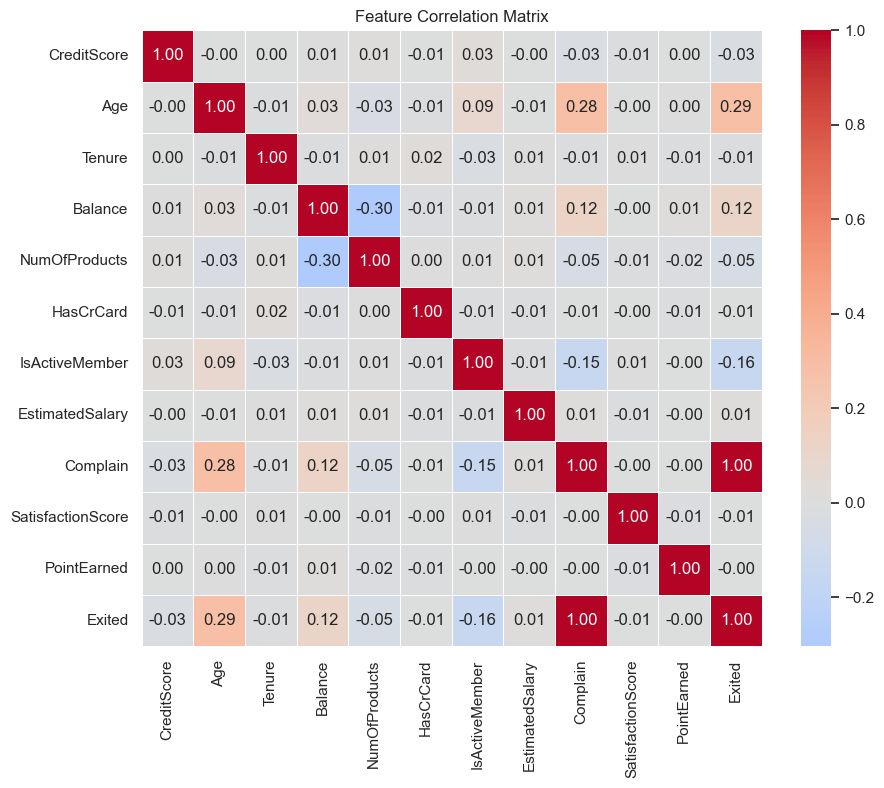

In [8]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")

plt.show()

### Insight

Complaint status is the stronger factors. Moreover, Customer age, account balance, and membership activity are pretty strong factors associated with churn. These areas should be prioritized for customer retention initiatives.

# Business Conclusion

Based on the exploratory analysis:

1. Germany exhibits the highest customer churn.
2. Inactive customers are significantly more likely to leave.
3. Customers with higher balances also tend to churn more frequently.
4. Complaint status is the strongest indicator of churn.
5. Customer retention initiatives should prioritize complaint handling, customer engagement, and high-value customer monitoring.

The findings from this notebook will be used to prepare the Gold Dataset for dashboard development in Looker Studio.

In [9]:
gold = df.copy()
gold = gold.drop(columns=["CustomerId"])

In [10]:
gold["Exited"] = gold["Exited"].map({
    0: "Stayed",
    1: "Churned"
})

gold["HasCrCard"] = gold["HasCrCard"].map({
    0: "No",
    1: "Yes"
})

gold["IsActiveMember"] = gold["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

gold["Complain"] = gold["Complain"].map({
    0: "No Complaint",
    1: "Complaint"
})

In [11]:
gold["AgeGroup"] = pd.cut(
    gold["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60",
        "60+"
    ],
    include_lowest=True
)

In [12]:
gold["BalanceRange"] = pd.cut(
    gold["Balance"],
    bins=[0, 50000, 100000, 150000, float("inf")],
    labels=[
        "0–50K",
        "50K–100K",
        "100K–150K",
        "150K+"
    ],
    include_lowest=True
)

In [18]:
gold["BalanceRangeOrder"] = gold["BalanceRange"].map({
    "0–50K": 1,
    "50K–100K": 2,
    "100K–150K": 3,
    "150K+": 4
})

In [19]:
gold["AgeGroupOrder"] = gold["AgeGroup"].map({
    "18-30": 1,         
    "31-45": 2,
    "46-60": 3,
    "60+": 4
})

In [15]:
gold = gold[
    [
        "Geography",
        "Gender",
        "AgeGroup",
        "BalanceRange",
        "NumOfProducts",
        "IsActiveMember",
        "Complain",
        "SatisfactionScore",
        "Exited"
    ]
]

In [16]:
gold.head()



,Geography,Gender,AgeGroup,BalanceRange,NumOfProducts,IsActiveMember,Complain,SatisfactionScore,Exited
0,France,Female,41-50,0–50K,1,Active,Complaint,2,Churned
1,Spain,Female,41-50,50K–100K,1,Active,Complaint,3,Stayed
2,France,Female,41-50,150K+,3,Inactive,Complaint,3,Churned
3,France,Female,31-40,0–50K,2,Inactive,No Complaint,5,Stayed
4,Spain,Female,41-50,100K–150K,1,Active,No Complaint,5,Stayed


In [17]:
import os
os.makedirs('data/gold', exist_ok=True)

gold.to_csv(
    'data/gold/customer_churn_gold.csv',
    index=False
)

print('Gold Layer successfully created!')

Gold Layer successfully created!
